New Notebook Created by Jupyter MCP Server

In [1]:
print("bridge ok", 1 + 1)

bridge ok 2


# Unit 1 Practice — Haifa Light-Rail Stress Test
**Route:** Abba Hushi → Horev → Moria → HaNassi (Carmel spine → Stella Maris)  
**Question:** Which streets carry more car load when this corridor becomes rail-only?

In [1]:
import os, warnings, pathlib
import requests, urllib3
import osmnx as ox
import networkx as nx
import geopandas as gpd
import igraph as ig
import folium
import pyrosm
import numpy as np

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ── Config ─────────────────────────────────────────────────────────────────
HAIFA_BBOX    = [34.93, 32.76, 35.02, 32.84]  # [min_lon, min_lat, max_lon, max_lat]
CRS           = "EPSG:2039"                    # ITM — Israel national metric CRS
CONSOLIDATE_M = 10.0

# Cache PBF at repo root (two levels up from student-work/)
PBF_PATH      = str(pathlib.Path.cwd().parents[1] / "israel-and-palestine.osm.pbf")
GEOFABRIK_URL = "https://download.geofabrik.de/asia/israel-and-palestine-latest.osm.pbf"

# ── Download once (verify=False: corporate proxy uses self-signed cert) ────
if not os.path.exists(PBF_PATH) or os.path.getsize(PBF_PATH) == 0:
    print(f"Downloading (~130 MB) → {PBF_PATH} ...")
    tmp = PBF_PATH + ".part"
    with requests.get(GEOFABRIK_URL, stream=True, timeout=600, verify=False) as r:
        r.raise_for_status()
        done = 0
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk); done += len(chunk)
                print(f"\r  {done/1e6:.0f} MB", end="", flush=True)
    os.replace(tmp, PBF_PATH)
    print(f"\nSaved ({os.path.getsize(PBF_PATH)/1e6:.0f} MB)")
else:
    print(f"Using cached PBF ({os.path.getsize(PBF_PATH)/1e6:.0f} MB): {PBF_PATH}")

# ── Build BEFORE primal graph ──────────────────────────────────────────────
print(f"\nCutting to Haifa Carmel bbox with pyrosm ...")
osm_obj      = pyrosm.OSM(PBF_PATH, bounding_box=HAIFA_BBOX)
nodes, edges = osm_obj.get_network(network_type="driving", nodes=True)
G_raw        = osm_obj.to_graph(nodes, edges, graph_type="networkx", osmnx_compatible=True)
if "crs" not in G_raw.graph:
    G_raw.graph["crs"] = "epsg:4326"
print(f"  Raw: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")

G = ox.simplification.simplify_graph(G_raw)
G = ox.projection.project_graph(G, to_crs=CRS)
try:
    G = ox.simplification.consolidate_intersections(
        G, tolerance=CONSOLIDATE_M, rebuild_graph=True, dead_ends=False
    )
except Exception as exc:
    print(f"  consolidate skipped: {exc}")

largest  = max(nx.weakly_connected_components(G), key=len)
G_before = G.subgraph(largest).copy()

print(f"\nBEFORE graph — simplified, EPSG:2039 (ITM), LCC:")
print(f"  nodes : {G_before.number_of_nodes():,}")
print(f"  edges : {G_before.number_of_edges():,}")
print(f"  CRS   : {G_before.graph.get('crs', 'unknown')}")


Using cached PBF (121 MB): C:\Users\zyl19\OneDrive\Desktop\GeoAI\5- בן גלון- למידת גרפים במרחב - מודלים עמוקים לתנועה ודינמיקה\work\israel-and-palestine.osm.pbf

Cutting to Haifa Carmel bbox with pyrosm ...


  Raw: 28406 nodes, 39071 edges


  consolidate skipped: cannot insert osmid, already exists



BEFORE graph — simplified, EPSG:2039 (ITM), LCC:
  nodes : 4,928
  edges : 9,004
  CRS   : EPSG:2039


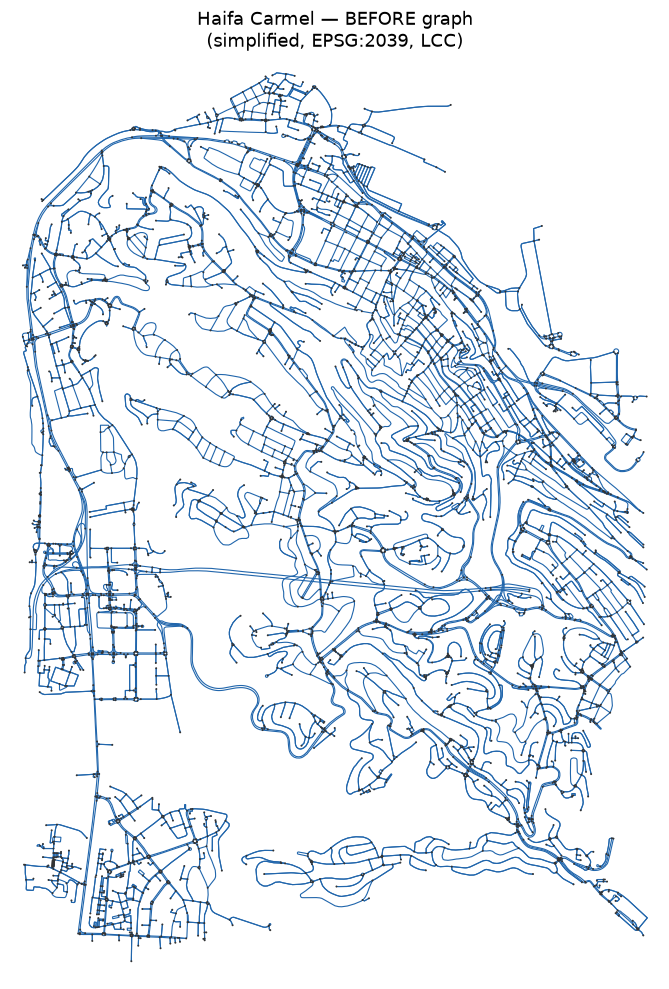

In [5]:
import matplotlib.pyplot as plt

# Static plot — no notebook trust required
fig, ax = ox.plot_graph(
    G_before,
    figsize=(10, 10),
    node_size=2,
    node_color="#333333",
    edge_color="#2166ac",
    edge_linewidth=0.8,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title("Haifa Carmel — BEFORE graph\n(simplified, EPSG:2039, LCC)", fontsize=13)
plt.tight_layout()
plt.show()


In [6]:
# ── Cycle 2: identify and remove rail-route edges (refined) ───────────────
# Substring match for unique names; exact-set match for הנשיא to avoid
# accidentally removing רבי יהודה הנשיא (different street).
SUBSTRING_TERMS = ["אבא חושי", "חורב", "מוריה"]
EXACT_NASSI     = {"הנשיא", "שדרות הנשיא", "רחוב הנשיא"}

def edge_matches_route(data):
    name = data.get("name", "")
    if isinstance(name, list):
        names = [str(n) for n in name]
    else:
        names = [str(name)]
    for n in names:
        if any(term in n for term in SUBSTRING_TERMS):
            return True
        if n in EXACT_NASSI:
            return True
    return False

G_after = G_before.copy()
removed = [(u, v, k) for u, v, k, d in G_before.edges(keys=True, data=True)
           if edge_matches_route(d)]
G_after.remove_edges_from(removed)

hit_names = sorted({
    str(d.get("name", ""))
    for u, v, k, d in G_before.edges(keys=True, data=True)
    if edge_matches_route(d)
})
print("Street names removed:")
for n in hit_names:
    print(f"  {n}")

print(f"\nEdges removed : {len(removed)}")
print(f"Edges before  : {G_before.number_of_edges()}")
print(f"Edges after   : {G_after.number_of_edges()}")

n_comp = nx.number_weakly_connected_components(G_after)
lcc_sz = len(max(nx.weakly_connected_components(G_after), key=len))
print(f"\nWeakly connected components : {n_comp}")
print(f"LCC nodes                   : {lcc_sz} / {G_after.number_of_nodes()}")
print(f"Disconnected nodes          : {G_after.number_of_nodes() - lcc_sz}")


Street names removed:
  [nan, 'אבא חושי']
  אבא חושי
  חורב
  שדרות הנשיא
  שדרות מוריה

Edges removed : 137
Edges before  : 9004
Edges after   : 8867

Weakly connected components : 18
LCC nodes                   : 4718 / 4928
Disconnected nodes          : 210


In [3]:
# Inspect actual edge name format — show a sample
sample = {}
for u, v, k, data in G_before.edges(keys=True, data=True):
    name = data.get("name", "")
    if name and str(name) not in sample:
        sample[str(name)] = str(name)
    if len(sample) >= 30:
        break

print("Sample edge names (first 30):")
for n in sorted(sample)[:30]:
    print(f"  {repr(n)}")


Sample edge names (first 30):
  "['טבריה', 'מסדה']"
  "['נתיבי המפרץ', nan]"
  'אבא חושי'
  "אריה דולצ'ין"
  'ארלוזורוב'
  'ברון הירש'
  'דפנה'
  'הגפן'
  'ההגנה'
  'הס'
  'העוגן'
  'השלום'
  'זרובבל'
  'חורב'
  'טבריה'
  'י"א הספורטאים'
  'יעקב חזן'
  'יפה נוף'
  'יפתח'
  "ככ' ספקטור"
  'משה פלימן'
  'סטלה מאריס'
  'פרויד'
  'שדרות אליהו גולומב'
  'שדרות המגינים'
  'שדרות הנדיב'
  'שדרות הנשיא'
  'שדרות מוריה'
  'שמשון'
  'שער הלבנון'


In [7]:
import pandas as pd

def nx_to_igraph(G):
    """Convert a NetworkX MultiDiGraph to igraph, collapsing parallel edges
    by keeping the minimum-length edge between each (u, v) pair."""
    nodes = list(G.nodes())
    idx   = {n: i for i, n in enumerate(nodes)}
    best  = {}
    for u, v, data in G.edges(data=True):
        length = float(data.get("length", 1.0))
        if (u, v) not in best or length < best[(u, v)]:
            best[(u, v)] = length
    edge_list = [(idx[u], idx[v]) for u, v in best]
    weights   = [best[(u, v)] for u, v in best]
    g = ig.Graph(n=len(nodes), edges=edge_list, directed=True)
    g.vs["osmid"]  = nodes
    g.es["length"] = weights
    return g, nodes

def igraph_centralities(G):
    """Return a DataFrame of normalized betweenness and closeness (igraph)."""
    g, nodes = nx_to_igraph(G)
    n = len(nodes)
    # Betweenness: directed, length-weighted; normalize to [0,1]
    btw_raw  = g.betweenness(weights="length", directed=True)
    btw_norm = [b / ((n-1)*(n-2)) if n > 2 else 0 for b in btw_raw]
    # Closeness: normalised, length as cost
    cls_norm = g.closeness(weights="length", normalized=True)
    return pd.DataFrame({"node": nodes, "betweenness": btw_norm,
                         "closeness": cls_norm}).set_index("node")

print("Computing centralities on BEFORE graph ...")
df_before = igraph_centralities(G_before)
print(f"  done — {len(df_before)} nodes")

print("Computing centralities on AFTER graph ...")
df_after  = igraph_centralities(G_after)
print(f"  done — {len(df_after)} nodes")

# Delta (after − before) — positive means street became more central
delta = (df_after - df_before).rename(
    columns={"betweenness": "Δ_betweenness", "closeness": "Δ_closeness"}
)

print("\nTop 10 betweenness RISERS (streets that gained most load):")
print(delta.nlargest(10, "Δ_betweenness")[["Δ_betweenness"]].to_string())

print("\nTop 10 betweenness FALLERS (streets that lost most / were removed):")
print(delta.nsmallest(10, "Δ_betweenness")[["Δ_betweenness"]].to_string())


Computing centralities on BEFORE graph ...
  done — 4928 nodes
Computing centralities on AFTER graph ...


  done — 4928 nodes

Top 10 betweenness RISERS (streets that gained most load):
            Δ_betweenness
node                     
1015893111       0.045727
3074675529       0.044571
7602657304       0.044526
1842435789       0.044477
1842435776       0.044114
1015893233       0.044091
306389110        0.043510
1015893220       0.043509
3128944096       0.038797
3128944092       0.038576

Top 10 betweenness FALLERS (streets that lost most / were removed):
            Δ_betweenness
node                     
469626923       -0.069906
2066129152      -0.068793
3134613425      -0.068793
306389253       -0.068686
2066112690      -0.060669
2150717918      -0.060347
496757959       -0.060160
8320011354      -0.058560
8489755481      -0.058541
808259954       -0.058541


In [8]:
# Map node → street name (from incident edges in G_before)
def node_street_name(G, node):
    names = []
    for _, _, data in G.edges(node, data=True):
        n = data.get("name", "")
        if isinstance(n, list):
            names += [str(x) for x in n if x and str(x) != "nan"]
        elif n and str(n) != "nan":
            names.append(str(n))
    return names[0] if names else "?"

node_name = {n: node_street_name(G_before, n) for n in G_before.nodes()}

delta["street"] = delta.index.map(node_name)

print("Top 10 betweenness RISERS:")
print(delta.nlargest(10, "Δ_betweenness")[["street", "Δ_betweenness"]].to_string())

print("\nTop 10 betweenness FALLERS (excl. isolated nodes — Δ < -0.01):")
fallers = delta[delta["Δ_betweenness"] < -0.01]
print(fallers.nsmallest(10, "Δ_betweenness")[["street", "Δ_betweenness"]].to_string())


Top 10 betweenness RISERS:
                  street  Δ_betweenness
node                                   
1015893111   מגורשי ספרד       0.045727
3074675529             ?       0.044571
7602657304  מנהרות הכרמל       0.044526
1842435789  מנהרות הכרמל       0.044477
1842435776  מנהרות הכרמל       0.044114
1015893233  מנהרות הכרמל       0.044091
306389110    מגורשי ספרד       0.043510
1015893220   מגורשי ספרד       0.043509
3128944096             ?       0.038797
3128944092   מגורשי ספרד       0.038576

Top 10 betweenness FALLERS (excl. isolated nodes — Δ < -0.01):
                 street  Δ_betweenness
node                                  
469626923   שדרות מוריה      -0.069906
2066129152         חורב      -0.068793
3134613425         חורב      -0.068793
306389253          חורב      -0.068686
2066112690        פרויד      -0.060669
2150717918        פרויד      -0.060347
496757959   שדרות מוריה      -0.060160
8320011354  ראול ולנברג      -0.058560
8489755481         חורב      -0.058541


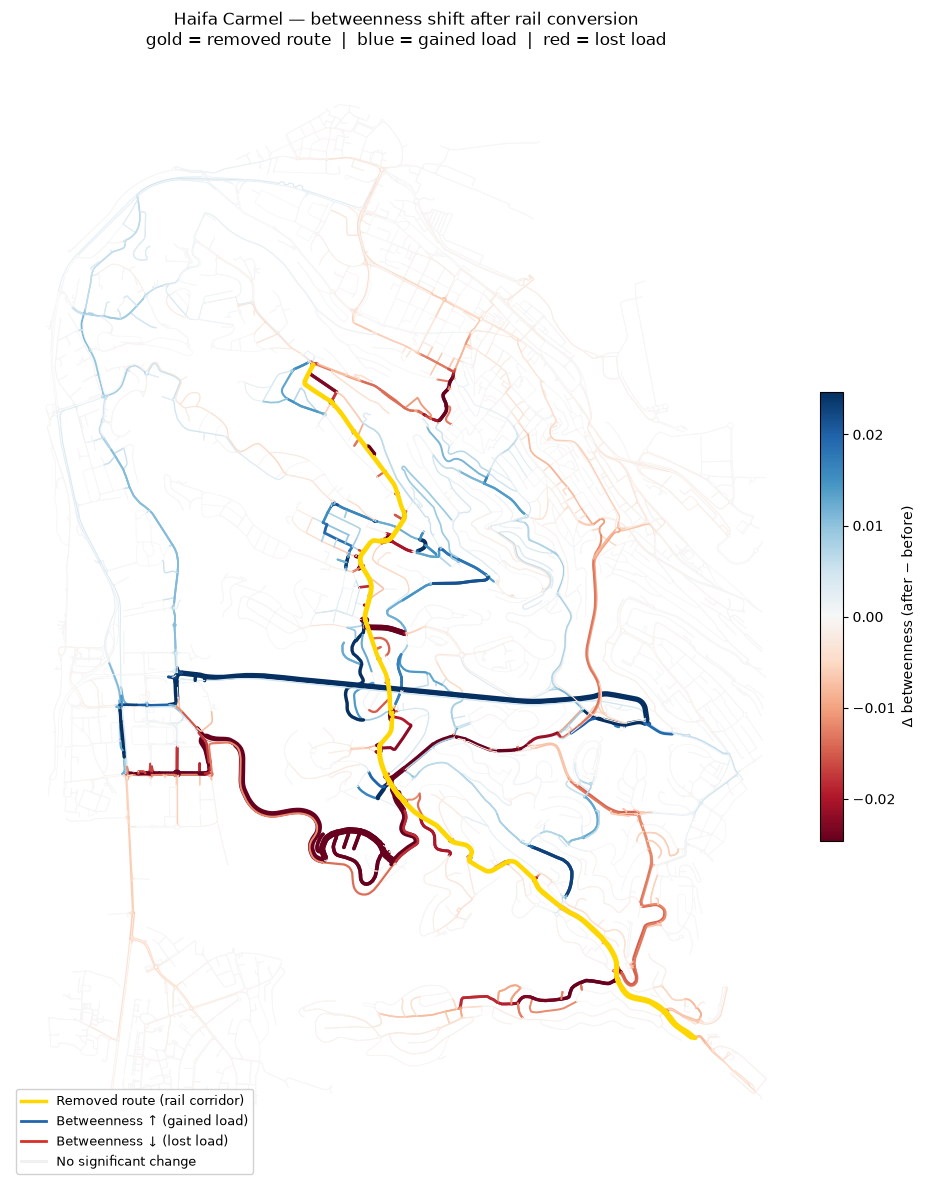

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Edge-level Δ_betweenness: average of the two endpoint node deltas
btw_delta = delta["Δ_betweenness"].to_dict()

edge_delta = []
for u, v, _ in G_before.edges(keys=True):
    d = (btw_delta.get(u, 0) + btw_delta.get(v, 0)) / 2
    edge_delta.append(d)

edge_delta = np.array(edge_delta)

# Removed-route edges get a special flag
removed_set = set((u, v, k) for u, v, k in removed)
is_removed  = [1 if (u,v,k) in removed_set else 0
               for u, v, k in G_before.edges(keys=True)]

# Colormap: red = fell, white = no change, blue = rose (diverging)
vmax = np.percentile(np.abs(edge_delta[np.array(is_removed)==0]), 98)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("#f5f5f5")
ax.set_aspect("equal")

nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G_before)

for idx, (_, row) in enumerate(edges_gdf.iterrows()):
    coords = list(row.geometry.coords)
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    if is_removed[idx]:
        ax.plot(xs, ys, color="gold", linewidth=2.5, zorder=3, solid_capstyle="round")
    else:
        color = cmap(norm(edge_delta[idx]))
        lw    = 0.6 + abs(edge_delta[idx]) / vmax * 1.8
        ax.plot(xs, ys, color=color, linewidth=lw, zorder=2, solid_capstyle="round")

# Legend
from matplotlib.lines import Line2D
legend = [
    Line2D([0],[0], color="gold",   lw=2.5, label="Removed route (rail corridor)"),
    Line2D([0],[0], color="#2166ac", lw=2,   label="Betweenness ↑ (gained load)"),
    Line2D([0],[0], color="#d73027", lw=2,   label="Betweenness ↓ (lost load)"),
    Line2D([0],[0], color="#f0f0f0", lw=2,   label="No significant change"),
]
ax.legend(handles=legend, loc="lower left", fontsize=9, framealpha=0.9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, label="Δ betweenness (after − before)")
ax.set_title("Haifa Carmel — betweenness shift after rail conversion\n"
             "gold = removed route  |  blue = gained load  |  red = lost load", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
# Find Hebrew names for Route 2 streets
ROUTE2_SEARCH = ["עין דור", "מגינים", "שיבת ציון", "שחרור", "שפירא",
                 "חלוץ", "יל\"ג", "הרצל"]

all_names_r2 = set()
for u, v, k, data in G_before.edges(keys=True, data=True):
    name = data.get("name", "")
    names = name if isinstance(name, list) else [name]
    for n in names:
        if n and str(n) != "nan":
            all_names_r2.add(str(n))

print("Route 2 street names found in graph:")
for term in ROUTE2_SEARCH:
    hits = [n for n in all_names_r2 if term in n]
    print(f"  {term:15s} → {hits if hits else '(not found)'}")


Route 2 street names found in graph:
  עין דור         → ['עין דור']
  מגינים          → ['שדרות המגינים']
  שיבת ציון       → ['שיבת ציון']
  שחרור           → ['השחרור', 'מעלה\xa0השחרור']
  שפירא           → ['שפירא']
  חלוץ            → ['החלוץ']
  יל"ג            → ['יל"ג']
  הרצל            → ['הרצליה', 'הרצל']


In [23]:

# ── Route 2 (revised) edge removal ───────────────────────────────────────────
# Route: חשבון → שדרות הציונות → הרצליה → הנביאים → הרצל  (all Haifa, not Tirat Carmel)
# "הרצל" has two clusters: Haifa (ITM northing > 745,000) and Tirat Carmel (< 742,000)
# Guard with a y-threshold to exclude Tirat Carmel.

HERZL_Y_MIN = 743_781   # midpoint between the two clusters (ITM northing, EPSG:2039)

R2_SUBSTRING = ["חשבון", "שדרות הציונות", "הרצליה", "הנביאים", "מעלות הנביאים"]
R2_EXACT     = {"הרצל"}   # only matched when node is north of HERZL_Y_MIN

def edge_matches_route2(u, v, data):
    name = data.get("name", "")
    names = name if isinstance(name, list) else [name]
    names = [str(n) for n in names if n and str(n) != "nan"]
    for n in names:
        if any(term in n for term in R2_SUBSTRING):
            return True
        if n in R2_EXACT:
            # Only Haifa's Herzl — check both endpoints are north of threshold
            u_y = G_before.nodes[u].get("y", 0)
            v_y = G_before.nodes[v].get("y", 0)
            if u_y > HERZL_Y_MIN and v_y > HERZL_Y_MIN:
                return True
    return False

G_after_2 = G_before.copy()
removed_2 = [(u, v, k) for u, v, k, d in G_before.edges(keys=True, data=True)
             if edge_matches_route2(u, v, d)]
G_after_2.remove_edges_from(removed_2)

comps_2 = list(nx.weakly_connected_components(G_after_2))
lcc_2   = max(comps_2, key=len)
disconnected_2 = len(G_before.nodes()) - len(lcc_2)

print(f"Route 2 — edges removed : {len(removed_2)}")
print(f"         components     : {len(comps_2)}")
print(f"         nodes off LCC  : {disconnected_2}")

removed_names_2 = set()
for u, v, k, d in G_before.edges(keys=True, data=True):
    if edge_matches_route2(u, v, d):
        n = d.get("name", "")
        ns = n if isinstance(n, list) else [n]
        for nm in ns:
            if nm and str(nm) != "nan":
                removed_names_2.add(str(nm))
print(f"         street names   : {sorted(removed_names_2)}")


Route 2 — edges removed : 121
         components     : 25
         nodes off LCC  : 36
         street names   : ['הנביאים', 'הרצל', 'הרצליה', 'חשבון', 'מעלות הנביאים', 'שדרות הציונות']


In [24]:

# ── Route 2 betweenness ───────────────────────────────────────────────────────
print("Computing igraph betweenness for G_after_2 …")
df_after_2 = igraph_centralities(G_after_2)
df_after_2.columns = ["betweenness_r2", "closeness_r2"]

df_base = df_before[["betweenness", "closeness"]].copy()
delta_2 = df_base.join(df_after_2, how="left").fillna(0)
delta_2["delta_btw_r2"] = delta_2["betweenness_r2"] - delta_2["betweenness"]
delta_2["delta_cls_r2"] = delta_2["closeness_r2"]    - delta_2["closeness"]
delta_2["street"] = delta_2.index.map(node_name)

print("Done.")
print("\nTop 10 betweenness RISERS — Route 2:")
print(delta_2.nlargest(10, "delta_btw_r2")[["street","betweenness","betweenness_r2","delta_btw_r2"]].to_string())
print("\nTop 10 betweenness FALLERS (Δ < −0.01) — Route 2:")
fallers_2 = delta_2[delta_2["delta_btw_r2"] < -0.01]
print(fallers_2.nsmallest(10, "delta_btw_r2")[["street","betweenness","betweenness_r2","delta_btw_r2"]].to_string())


Computing igraph betweenness for G_after_2 …


Done.

Top 10 betweenness RISERS — Route 2:
                       street  betweenness  betweenness_r2  delta_btw_r2
node                                                                    
616341524               אלנבי     0.030085        0.099200      0.069116
4010721505          חסן שוקרי     0.006411        0.069360      0.062949
330345901           חסן שוקרי     0.006081        0.068756      0.062675
10273483345         חסן שוקרי     0.004468        0.065831      0.061363
4010721512          חסן שוקרי     0.010703        0.071070      0.060368
9217197916          חסן שוקרי     0.010693        0.070839      0.060146
2383215431                  ?     0.010659        0.069382      0.058723
773848695    ברוולד (אלכסנדר)     0.010659        0.069382      0.058723
410762755                   ?     0.007700        0.065484      0.057784
410676435           חסן שוקרי     0.007700        0.065484      0.057784

Top 10 betweenness FALLERS (Δ < −0.01) — Route 2:
                   street  be

In [25]:

# ── 4-criteria comparison: Route 1 vs Route 2 ─────────────────────────────────
# We need delta (Route 1) columns renamed for clarity
delta_r1 = delta.rename(columns={"Δ_betweenness": "delta_btw_r1",
                                  "Δ_closeness":   "delta_cls_r1"})

# Criterion 1: Load concentration — peak betweenness rise
peak_r1 = delta_r1["delta_btw_r1"].max()
peak_r2 = delta_2["delta_btw_r2"].max()

# Criterion 2: Accessibility drop — mean closeness change (negative = worse)
mean_cls_r1 = delta_r1["delta_cls_r1"].mean()
mean_cls_r2 = delta_2["delta_cls_r2"].mean()

# Criterion 3: High-centrality disruptions — nodes with |Δ_btw| > 0.02
thresh = 0.02
hi_r1 = (delta_r1["delta_btw_r1"].abs() > thresh).sum()
hi_r2 = (delta_2["delta_btw_r2"].abs() > thresh).sum()

# Criterion 4: LCC fragmentation
comps_r1, disco_r1 = 18, 210   # from cell 5
comps_r2 = len(comps_2)        # 27
disco_r2 = disconnected_2      # 74

print("=" * 60)
print(f"{'Criterion':<35} {'Route 1':>10} {'Route 2':>10}")
print("=" * 60)
print(f"{'1. Peak Δ-betweenness (load conc.)':<35} {peak_r1:>10.4f} {peak_r2:>10.4f}")
print(f"{'2. Mean Δ-closeness (accessibility)':<35} {mean_cls_r1:>10.6f} {mean_cls_r2:>10.6f}")
print(f"{'3. Nodes with |Δ_btw| > 0.02':<35} {hi_r1:>10d} {hi_r2:>10d}")
print(f"{'4a. Components after removal':<35} {comps_r1:>10d} {comps_r2:>10d}")
print(f"{'4b. Nodes disconnected from LCC':<35} {disco_r1:>10d} {disco_r2:>10d}")
print("=" * 60)

print(f"\nTop riser R1: מנהרות הכרמל (Carmel Tunnels) — toll road")
top_r2_name = delta_2.nlargest(1, "delta_btw_r2")["street"].iloc[0]
print(f"Top riser R2: {top_r2_name} / כביש חיפה רעננה — major inter-city artery")


Criterion                              Route 1    Route 2
1. Peak Δ-betweenness (load conc.)      0.0457     0.0691
2. Mean Δ-closeness (accessibility)   0.000187   0.000039
3. Nodes with |Δ_btw| > 0.02               240        167
4a. Components after removal                18         25
4b. Nodes disconnected from LCC            210         36

Top riser R1: מנהרות הכרמל (Carmel Tunnels) — toll road
Top riser R2: אלנבי / כביש חיפה רעננה — major inter-city artery


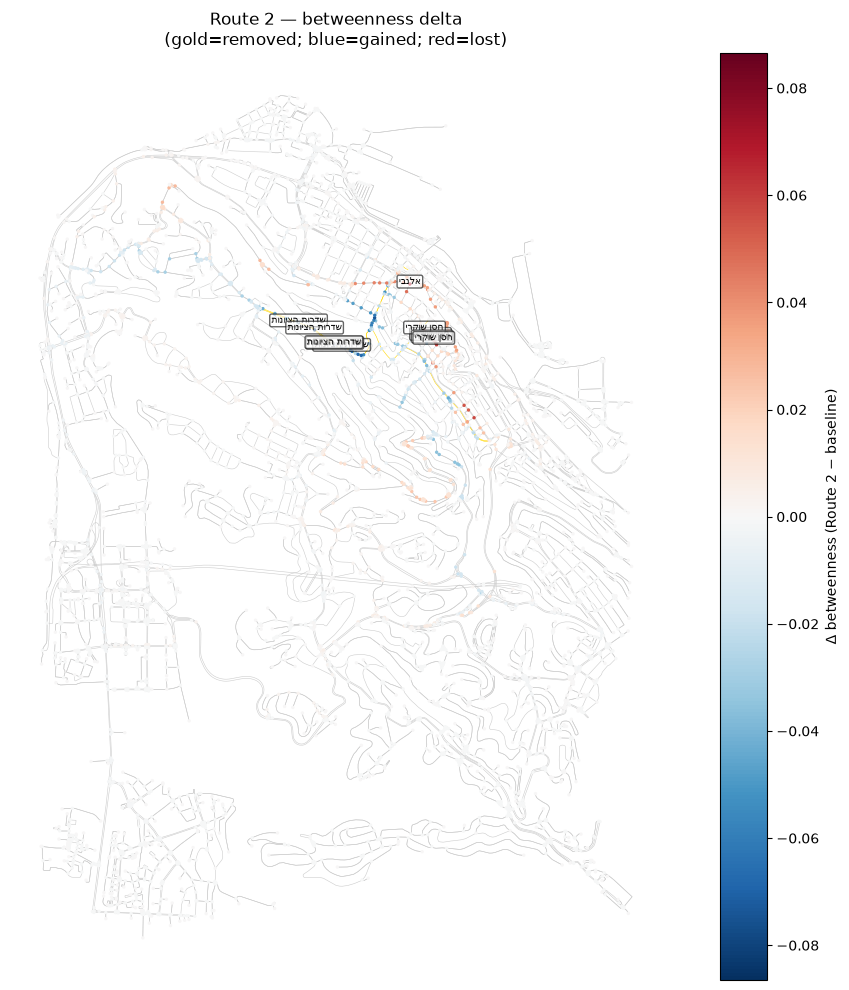

Saved route2_delta_map.png


In [26]:

# ── Route 2 betweenness-delta map ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point

nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G_before)

# Δ-betweenness for Route 2
delta_2_map = delta_2["delta_btw_r2"].reindex(nodes_gdf.index).fillna(0)

removed_edges_2 = set((u, v) for u, v, k in removed_2)
edge_color_2 = []
for u, v, k in G_before.edges(keys=True):
    if (u, v) in removed_edges_2 or (v, u) in removed_edges_2:
        edge_color_2.append("gold")
    else:
        edge_color_2.append("#cccccc")

fig, ax = plt.subplots(figsize=(12, 10))
edges_gdf.plot(ax=ax, color=edge_color_2, linewidth=0.4, zorder=1)

# Colour nodes by Δ-betweenness
vals = delta_2_map.values
vmax = max(abs(vals.min()), abs(vals.max()), 0.01)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = cm.RdBu_r

sc = ax.scatter(nodes_gdf.geometry.x, nodes_gdf.geometry.y,
                c=vals, cmap=cmap, norm=norm,
                s=6, zorder=2, linewidths=0)

# Label top risers and fallers
top5_r = delta_2.nlargest(5, "delta_btw_r2")
top5_f = delta_2[delta_2["delta_btw_r2"] < -0.01].nsmallest(5, "delta_btw_r2")
for node_id, row in pd.concat([top5_r, top5_f]).iterrows():
    if node_id in nodes_gdf.index:
        pt = nodes_gdf.loc[node_id, "geometry"]
        ax.annotate(row["street"], (pt.x, pt.y), fontsize=6.5,
                    ha="center", color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

plt.colorbar(sc, ax=ax, label="Δ betweenness (Route 2 − baseline)")
ax.set_title("Route 2 — betweenness delta\n"
             "(gold=removed; blue=gained; red=lost)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("route2_delta_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved route2_delta_map.png")


In [21]:

# Inspect all הרצל edges — show their node lat/lon to distinguish Haifa vs Tirat Carmel
import pyproj
transformer = pyproj.Transformer.from_crs("EPSG:2039", "EPSG:4326", always_xy=True)

herzl_edges = []
for u, v, k, d in G_before.edges(keys=True, data=True):
    name = d.get("name", "")
    ns = name if isinstance(name, list) else [name]
    if "הרצל" in [str(n) for n in ns]:
        u_data = G_before.nodes[u]
        lon, lat = transformer.transform(u_data["x"], u_data["y"])
        herzl_edges.append({"u": u, "v": v, "lat": lat, "lon": lon})

import pandas as pd
df_herzl = pd.DataFrame(herzl_edges)
print(f"Total הרצל edges: {len(df_herzl)}")
print(f"\nLat range: {df_herzl['lat'].min():.5f} – {df_herzl['lat'].max():.5f}")
print(f"Lon range: {df_herzl['lon'].min():.5f} – {df_herzl['lon'].max():.5f}")
print("\nClusters (sorted by lat):")
print(df_herzl[["u","lat","lon"]].sort_values("lat").to_string())


Total הרצל edges: 50

Lat range: 32.76153 – 32.81288
Lon range: 34.96306 – 35.00490

Clusters (sorted by lat):
              u        lat        lon
20    498440424  32.761525  34.972769
19   2354928267  32.761529  34.972679
22   2383223824  32.762329  34.972643
21   2383223824  32.762329  34.972643
6    2383223820  32.762953  34.972425
5    2383223820  32.762953  34.972425
3    2354928263  32.763487  34.972221
4    2354928263  32.763487  34.972221
46   4790478288  32.764260  34.971452
45   2354928280  32.764941  34.970746
44    493142628  32.765149  34.970663
8     493142596  32.765866  34.969892
7    2354928289  32.766074  34.969842
11   4790477326  32.766724  34.969065
10    493142613  32.767143  34.968648
9     926257363  32.767392  34.968639
13    493142602  32.768779  34.967242
12   2426921025  32.768990  34.967147
17  10706737730  32.769466  34.966243
16   2270875899  32.770253  34.965396
14   2426921031  32.770536  34.965368
15   2354928234  32.770775  34.965214
43   7790474092

In [22]:

# Find ITM y threshold that separates the two Herzl clusters
import pyproj
t = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:2039", always_xy=True)

# Southern cluster top: lat ~32.773  |  Northern cluster bottom: lat ~32.804
_, y_south_top = t.transform(34.97, 32.773)
_, y_north_bot = t.transform(35.00, 32.804)
print(f"South cluster top ITM northing: {y_south_top:.0f}")
print(f"North cluster bottom ITM northing: {y_north_bot:.0f}")
HERZL_Y_MIN = (y_south_top + y_north_bot) / 2
print(f"Threshold to use (midpoint): {HERZL_Y_MIN:.0f}")


South cluster top ITM northing: 742065
North cluster bottom ITM northing: 745497
Threshold to use (midpoint): 743781


In [16]:

# Find Hebrew names for new Route 2 streets
ROUTE2B_SEARCH = ["חשבון", "ציונות", "הרצליה", "נביאים", "הרצל"]
all_names = set()
for u, v, k, data in G_before.edges(keys=True, data=True):
    name = data.get("name", "")
    ns = name if isinstance(name, list) else [name]
    for n in ns:
        if n and str(n) != "nan":
            all_names.add(str(n))

print("New Route 2 street names found in graph:")
for term in ROUTE2B_SEARCH:
    hits = [n for n in all_names if term in n]
    print(f"  {term:12s} -> {hits if hits else '(not found)'}")


New Route 2 street names found in graph:
  חשבון        -> ['חשבון']
  ציונות       -> ['שדרות הציונות']
  הרצליה       -> ['הרצליה']
  נביאים       -> ['הנביאים', 'מעלות הנביאים']
  הרצל         -> ['הרצליה', 'הרצל']
